# Task 07 – Explainable AI Analysis

Interprets the best-performing model from Task 6 (**Logistic Regression**) using **SHAP**
(SHapley Additive exPlanations), to understand which features drive each disease-risk prediction
and how transparent/trustworthy the model's reasoning is.

In [ ]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

lr = joblib.load('../models/logistic_regression.pkl')
split = joblib.load('../models/train_test_split.pkl')
X_train, X_test, y_test = split['X_train'], split['X_test'], split['y_test']

shap.initjs()

## Building the explainer

Logistic Regression is a linear model, so we use `shap.LinearExplainer`, which computes exact SHAP
values efficiently for linear models (no sampling approximation needed, unlike model-agnostic
explainers).

In [ ]:
explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

class_names = list(lr.classes_)
print('Classes:', class_names)
print('Raw SHAP output shape:', np.array(shap_values).shape)

# Normalize to a helper: get_class_shap(class_label) -> (n_samples, n_features) array
def get_class_shap(class_label):
    idx = class_names.index(class_label)
    if isinstance(shap_values, list):
        return shap_values[idx]
    else:
        # shap_values shape: (n_samples, n_features, n_classes)
        return shap_values[:, :, idx]

print('Per-class SHAP shape (example, High):', get_class_shap('High').shape)

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


Classes: ['High', 'Low', 'Medium']
Raw SHAP output shape: (200, 66, 3)
Per-class SHAP shape (example, High): (200, 66)


## Global feature importance

Mean absolute SHAP value per feature, averaged across all three risk classes — this shows which
features matter most to the model overall.

In [3]:
mean_abs_shap = np.mean([np.abs(get_class_shap(c)).mean(axis=0) for c in class_names], axis=0)

importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
importance.head(15)

blood_sugar_mg_dl               4.247989
cholesterol_mg_dl               4.156089
age                             3.750567
bmi                             3.465196
previous_admissions             2.408942
systolic_bp                     1.706314
bmi_category_Obese              0.297635
consultation_fee_lkr            0.276097
missed_appointment_rate         0.234086
bmi_category_Overweight         0.233394
missed_previous_appointments    0.231639
appointment_status_No-Show      0.202618
diagnosis_Migraine              0.190433
waiting_days                    0.165830
payment_method_Cash             0.165185
dtype: float64

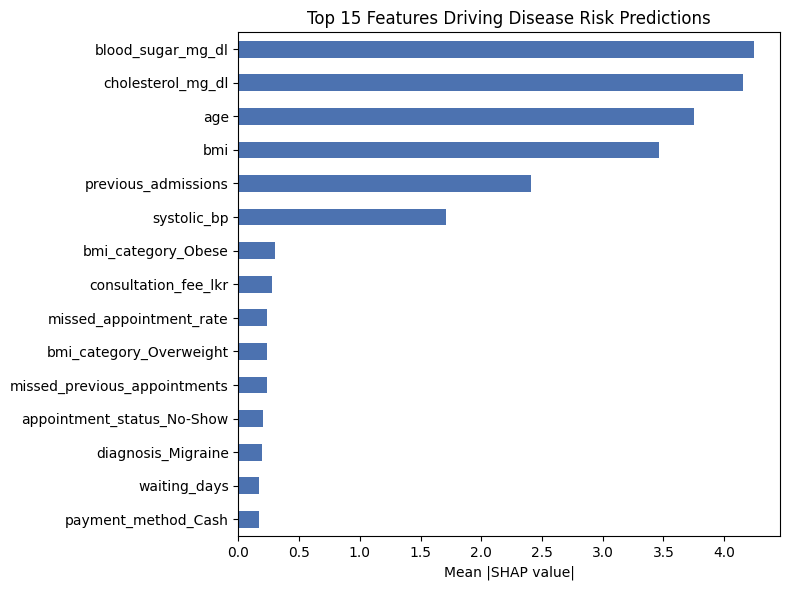

In [4]:
plt.figure(figsize=(8, 6))
importance.head(15).sort_values().plot(kind='barh', color='#4C72B0')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 Features Driving Disease Risk Predictions')
plt.tight_layout()
plt.savefig('../models/shap_global_importance.png', dpi=120)
plt.show()

## Class-specific summary plot (High risk)

Shows, for the `High` risk class specifically, how each feature's value (red = high, blue = low)
pushes the prediction toward or away from High risk.

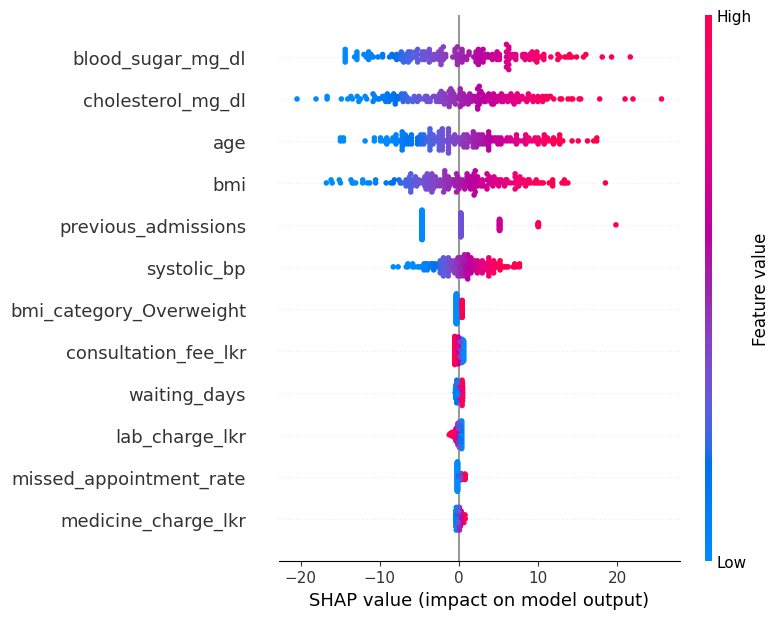

In [5]:
sv_high = get_class_shap('High')

shap.summary_plot(sv_high, X_test, show=False, max_display=12)
plt.tight_layout()
plt.savefig('../models/shap_summary_high_risk.png', dpi=120)
plt.show()

## Local explanation – a single patient

Explaining one individual test-set prediction, to demonstrate what a clinician using the
Task 8 prototype would see: which factors pushed this specific patient's prediction toward or
away from their predicted class.

In [6]:
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = lr.predict(sample)[0]
pred_proba = lr.predict_proba(sample)[0]

print('True label:', true_label)
print('Predicted label:', pred_label)
print('Predicted probabilities:', dict(zip(lr.classes_, pred_proba.round(3))))

sv_sample = get_class_shap(pred_label)[sample_idx]

contrib = pd.Series(sv_sample, index=X_test.columns).sort_values(key=abs, ascending=False)
contrib.head(10)

True label: Medium
Predicted label: Medium
Predicted probabilities: {'High': np.float64(0.0), 'Low': np.float64(0.005), 'Medium': np.float64(0.995)}


blood_sugar_mg_dl               0.649641
bmi                             0.573768
blood_group_O-                 -0.302635
appointment_status_Completed    0.280875
medicine_charge_lkr             0.270307
appointment_status_No-Show     -0.264598
previous_appointments          -0.252112
waiting_days                    0.214239
diastolic_bp                   -0.202464
diagnosis_Fracture              0.199725
dtype: float64

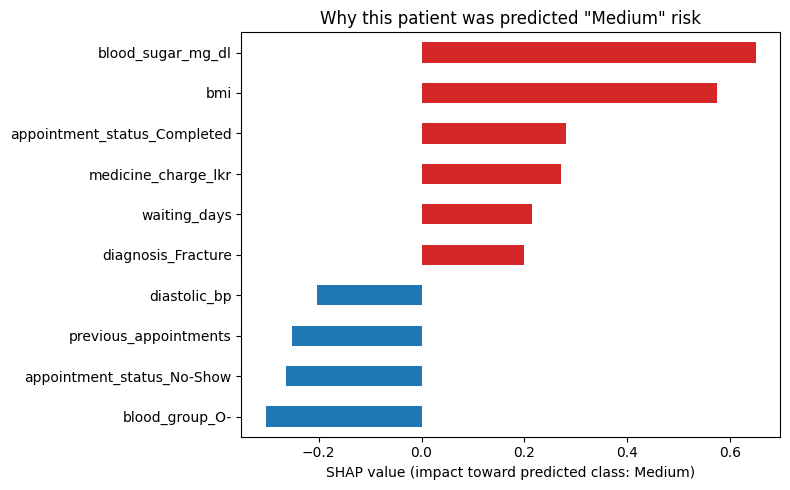

In [7]:
plt.figure(figsize=(8,5))
top_contrib = contrib.head(10).sort_values()
colors = ['#d62728' if v > 0 else '#1f77b4' for v in top_contrib.values]
top_contrib.plot(kind='barh', color=colors)
plt.xlabel(f'SHAP value (impact toward predicted class: {pred_label})')
plt.title(f'Why this patient was predicted "{pred_label}" risk')
plt.tight_layout()
plt.savefig('../models/shap_local_explanation.png', dpi=120)
plt.show()